# Tidy Data Project

### Cleaning and Tidying Process:

In [2]:
# Import neccesary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import dataframe
olympics = pd.read_csv("data/olympics_08_medalists.csv")
df = pd.DataFrame(olympics)

#Examine the dataframe
df.head(20)

,medalist_name,male_archery,female_archery,male_athletics,female_athletics,male_badminton,female_badminton,male_baseball,male_basketball,female_basketball,...,female_beach volleyball,male_volleyball,female_volleyball,male_water polo,female_water polo,male_weightlifting,female_weightlifting,male_freestyle wrestling,female_freestyle wrestling,male_greco-roman wrestling
0,Aaron Armstrong,NaN,NaN,gold,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aaron Peirsol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Abdullo Tangriev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Abeer Abdelrahman,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,bronze,NaN,NaN,NaN
4,Abhinav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Acer Nethercott,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Adam Korol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Adam Kreek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Adam Pine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Adam Wheeler,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bronze


After importing in our data, we need to make it into a dataframe. Dataframes allow us to analyze and apply methods to our orginal dataset. The command .head() allows us to visualize the structure of the dataframe. As we can see, it is currently rather untidy. According to "Tidy Data" by Hadley Wickham, each variable should have its own column, each observation should form its own row, and each type of observational unit should form its own table. However, this dataframe shows multiple variables per column, and in all rows, there are a large quantity of NaN values present. 

In [3]:
#Melt the dataframe: 

id_cols = ["medalist_name"]
value_cols = [col for col in df.columns if col not in id_cols]

dfm = pd.melt(df, 
        id_vars = id_cols,
        value_vars= value_cols, 
        var_name = "Sport", 
        value_name = "medal")
dfm

,medalist_name,Sport,medal
0,Aaron Armstrong,male_archery,NaN
1,Aaron Peirsol,male_archery,NaN
2,Abdullo Tangriev,male_archery,NaN
3,Abeer Abdelrahman,male_archery,NaN
4,Abhinav,male_archery,NaN
...,...,...,...
131245,Éver Banega,male_greco-roman wrestling,NaN
131246,Ólafur Stefánsson,male_greco-roman wrestling,NaN
131247,Óscar Brayson,male_greco-roman wrestling,NaN
131248,Łukasz Pawłowski,male_greco-roman wrestling,NaN


Referencing the Pandas Data Wrangling Cheat Sheet, I decide to use pd.melt() to put my columns into rows. Melting allows us to condense the dataframe's information into a reduced number columns (typically three), providing a cleaner overview of the dataset. 

The unique identify for the dataframe is a medalist's name. Thus, I melt all other rows which are not the medalist's name. I make my new value column "medal" and the new var_name column hold all sport titles. 

In [4]:
#Split the "Sport" column based on sex
split_data = dfm["Sport"].str.split("_", expand = True)
split_data

#Add new columns back to the original df: 
dfm[["sex", "sport_name"]] = split_data

#Get rid of old "Sport Column"
dfm = dfm.drop(columns=["Sport"])
dfm

,medalist_name,medal,sex,sport_name
0,Aaron Armstrong,NaN,male,archery
1,Aaron Peirsol,NaN,male,archery
2,Abdullo Tangriev,NaN,male,archery
3,Abeer Abdelrahman,NaN,male,archery
4,Abhinav,NaN,male,archery
...,...,...,...,...
131245,Éver Banega,NaN,male,greco-roman wrestling
131246,Ólafur Stefánsson,NaN,male,greco-roman wrestling
131247,Óscar Brayson,NaN,male,greco-roman wrestling
131248,Łukasz Pawłowski,NaN,male,greco-roman wrestling


However, the "Sport" column still contains two variables: a sport's title and the sex of the participant. To seperate these variables, I use .str.split to split the "Sport" column by the delimiter "_". I assign the split columns to the variable "split_data". Then, I put these new columns back into the original dataframe and delete the original messy source "Sport" column. 

In [5]:
#Drop all NaN medal values
dfm = dfm.dropna()
dfm

,medalist_name,medal,sex,sport_name
177,Bair Badënov,bronze,male,archery
676,Ilario Di Buò,silver,male,archery
682,Im Dong-hyun,gold,male,archery
760,Jiang Lin,bronze,male,archery
920,Lee Chang-hwan,gold,male,archery
...,...,...,...,...
130932,Steeve Guénot,gold,male,greco-roman wrestling
131159,Yannick Szczepaniak,bronze,male,greco-roman wrestling
131162,Yavor Yanakiev,bronze,male,greco-roman wrestling
131200,Yury Patrikeyev,bronze,male,greco-roman wrestling


A tidy dataset also requires that there is a single observation in all rows and that each observational unit forms its own table, meaning we should get rid of NA values. We do not want there to be multiple NA listings for a singular medalist. We only want the medalist to be listed if they won a medal in a particular event. To drop my NA values, I use .dropna() and reassign the final clean dataset to variable "dfm". 

### Visualizations of Clean Data:

In [6]:
##Go to data to viz to look at ideas for EDA 
import seaborn as sns 

#Examine final dataframe:
dfm.describe()

,medalist_name,medal,sex,sport_name
count,1875,1875,1875,1875
unique,1875,3,2,38
top,Bair Badënov,bronze,male,athletics
freq,1,668,1032,166


To create visualizations of the data, I load in the library seaborn and look at my dataframe again using .describe(). Since my variables reflect categorical and ordinal information, I think it would be best to create bar and count charts.

Visualiztion One:

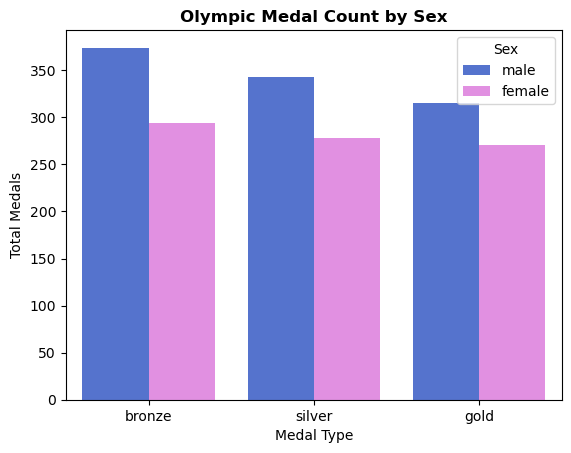

In [30]:
#Create a count plot showing the quanity of medals received by each sex

sns.countplot(dfm, x = "medal", hue = "sex", palette=["royalblue", "violet"])
plt.title("Olympic Medal Count by Sex",fontweight='bold')
plt.xlabel("Medal Type")
plt.ylabel("Total Medals")
plt.legend(title = "Sex")
plt.show()

My first graph shows the total number of different olympic medals received by each sex. I use .countplot() to get the total count of metals and then color the graph's bars according to a medalist's sex. This visualization shows the dataset's gender differences in medal acheivement. Examining the graph, we can see that this dataset possesses more men's than women's results. 

Visualization Two:

In [8]:
#Create a plot which shows the total medals for the top five sports

#Group the dataframe by sport type and summarize the total medals
summary = dfm.groupby("sport_name")["medal"].agg("count").reset_index()

#Sort the medal count into descending order and choose the top five sports which have the most medals
summary = summary.sort_values(by = "medal", ascending= False).head(5)
summary


,sport_name,medal
3,athletics,166
23,rowing,141
27,swimming,125
2,association football,109
14,field hockey,98


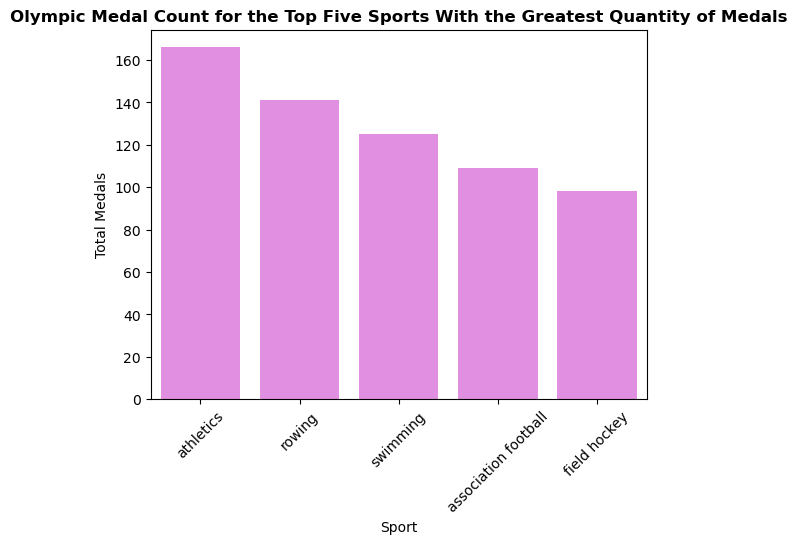

In [31]:
#Create the bar chart
sns.barplot(summary, x = "sport_name", y = "medal", color = "violet")
plt.title("Olympic Medal Count for the Top Five Sports With the Greatest Quantity of Medals", fontweight='bold')
plt.xlabel("Sport")
plt.ylabel("Total Medals")
plt.xticks(rotation = 45)
plt.show()

For my second visualization, I create a plot that shows the medals for the top five most winning sports in the dataset. To shape my dataset, I first use .groupby() to group all of sport_names together and .agg("count") to total up the number of medals for each sport. Next, I sort my new subsample, "summary", in descending order, using .sort_values(). I utilize .head(5) to only pull the top five values. Reassigning this information to "summary", I use the dataset in a .barplot() where "sport_name" is on the x-axis and "medal" is on the y axis. Looking at the top five sports with the most medals shows what areas atheletes in this dataset preformed best. This information could help a country indentify strong areas in their athletics programs. 

Visualization Three: 

In [10]:
#Create a plot which shows the total medals for the least winning five sports

#Group the dataframe by sport type and summarize the total medals
least_wins = dfm.groupby("sport_name")["medal"].agg("count").reset_index()

#Sort the medal count into asecending order and choose the top five sports which have the least amount of medals
least_wins = least_wins.sort_values(by = "medal").head(5)
least_wins

,sport_name,medal
19,modern pentathlon,5
34,triathlon,6
33,trampoline gymnastics,6
20,mountain biking,6
8,bmx,6


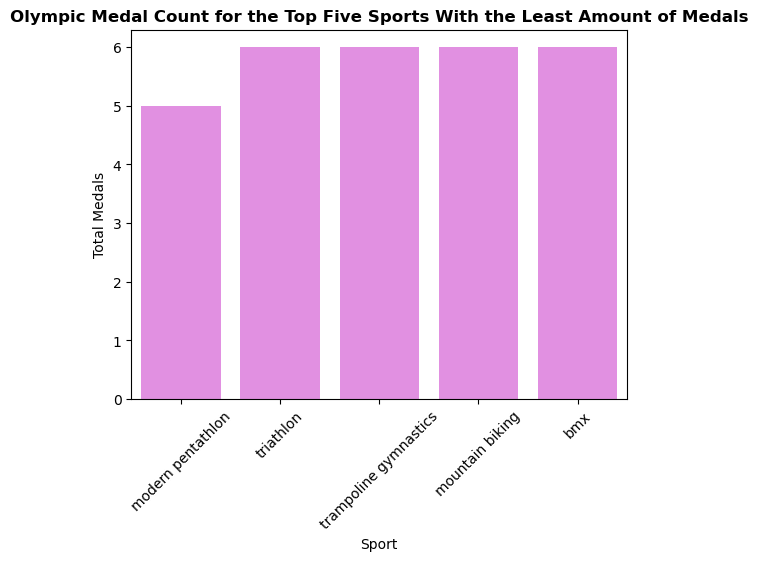

In [25]:
#Create the bar chart

sns.barplot(least_wins, x = "sport_name", y = "medal", color = "violet")
plt.title("Olympic Medal Count for the Top Five Sports With the Least Amount of Medals", fontweight='bold')
plt.xlabel("Sport")
plt.ylabel("Total Medals")
plt.xticks(rotation = 45)
plt.show()

For my final visualization, I follow a similar process to visualization two. However, this time, I choose to show the top five sports will the least amount of medals.
To shape my dataset, I first use .groupby() to group all of sport_names together and .agg("count") to total up the number of medals for each sport. Next, I sort my new subsample, "least_wins", in ascending order, using .sort_values() and use .head(5) to only pull the top five values. Reassigning this information to "least_wins", I use the dataset in a .barplot() where "sport_name" is on the x-axis and "medal" is on the y axis. Looking at the top five sports with the least amount of medals shows what areas atheletes in this dataset preformed worse. This information could help a country indentify weak areas in their athletics programs.

### Pivot Table:

In [12]:
#Pivot the final, clean dataframe to show how many medals each sex got in each sport
dfm_pivot_table = dfm.pivot_table(index = "sport_name", 
                                  columns = "sex", 
                                  values = "medal", 
                                  aggfunc = "count")
#Present the pivoted table:
dfm_pivot_table

sex,female,male
sport_name,,
archery,9.0,11.0
artistic gymnastics,20.0,29.0
association football,54.0,55.0
athletics,81.0,85.0
badminton,10.0,12.0
baseball,NaN,72.0
basketball,36.0,35.0
beach volleyball,6.0,6.0
bmx,3.0,3.0



For my pivot table, I decided to utilize a count aggregate function on the tidy data. I wanted to see how many medals were received by each sex in each sport.  

Taking my dataframe, I use the function .pivot_table. Within .pivot_table, I make my index "sport_name" and my columns "sex". The variable "medal" composes my value column. The final product shows the total number of medals received in each sport by sex. Since men and women both have the same number of events in the olympics, this pivot table shows that the dataset does not equally represent male and female game results. In many of the listed sports, men have more medals than women.